In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap  # Added for model explainability

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [14]:
# ------------------------------------------------------------
# 1. Load and explore the dataset
# ------------------------------------------------------------
gold_data = pd.read_csv('Gold Historical Data.csv')

print("First 5 rows:")
print(gold_data.head())
print("\nLast 5 rows:")
print(gold_data.tail())
print("\nDataset shape:", gold_data.shape)

# Missing values
print("\nMissing values per column:")
print(gold_data.isnull().sum())

# Statistical summary
print("\nStatistical description:")
print(gold_data.describe())

First 5 rows:
        Date     Price      Open      High       Low     Vol. Change %
0  3/11/2026  5,183.95  5,205.40  5,230.90  5,157.20  130.13K   -1.11%
1  3/10/2026  5,242.10  5,152.40  5,248.70  5,127.10  179.58K    2.71%
2   3/9/2026  5,103.70  5,186.70  5,210.40  5,021.20  181.75K   -1.07%
3   3/6/2026  5,158.70  5,099.70  5,185.00  5,071.00  160.27K    1.58%
4   3/5/2026  5,078.70  5,155.70  5,204.30  5,058.90  151.85K   -1.09%

Last 5 rows:
          Date     Price      Open      High       Low     Vol. Change %
2230  1/8/2016  1,097.90  1,108.80  1,113.10  1,091.80  193.45K   -0.89%
2231  1/7/2016  1,107.80  1,093.70  1,109.90  1,091.10  217.27K    1.46%
2232  1/6/2016  1,091.90  1,076.80  1,094.90  1,074.40  191.80K    1.25%
2233  1/5/2016  1,078.40  1,073.50  1,081.50  1,071.90  104.64K    0.30%
2234  1/4/2016  1,075.20  1,061.50  1,083.00  1,061.00  159.79K    1.41%

Dataset shape: (2235, 7)

Missing values per column:
Date        0
Price       0
Open        0
High        

In [15]:
# ------------------------------------------------------------
# 2. Data preprocessing
# ------------------------------------------------------------
# Convert Date to datetime
gold_data['Date'] = pd.to_datetime(gold_data['Date'], format='%m/%d/%Y')

# Convert price columns (Price, Open, High, Low) to float (remove commas)
for col in ['Price', 'Open', 'High', 'Low']:
    gold_data[col] = (
        gold_data[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# Convert volume column (e.g., "130.13K" -> 130130.0, "1.2M" -> 1200000.0)
vol = gold_data['Vol.'].astype(str).str.replace(',', '', regex=False)
vol = vol.str.replace('K', 'e3', regex=False).str.replace('M', 'e6', regex=False)
gold_data['Vol.'] = pd.to_numeric(vol, errors='coerce')

# Convert Change % to float (e.g., "-1.11%" -> -1.11)
gold_data['Change %'] = (
    gold_data['Change %']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

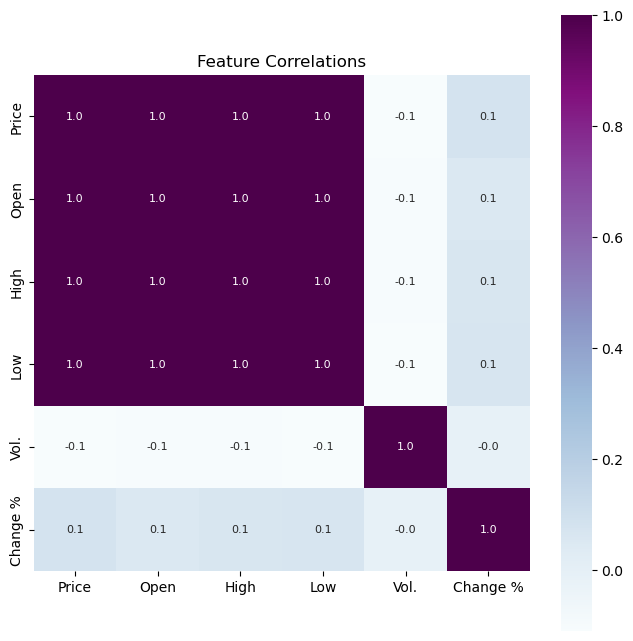


Correlation with Price:
Price       1.000000
Open        0.999398
High        0.999603
Low         0.999811
Vol.       -0.108536
Change %    0.078035
Name: Price, dtype: float64


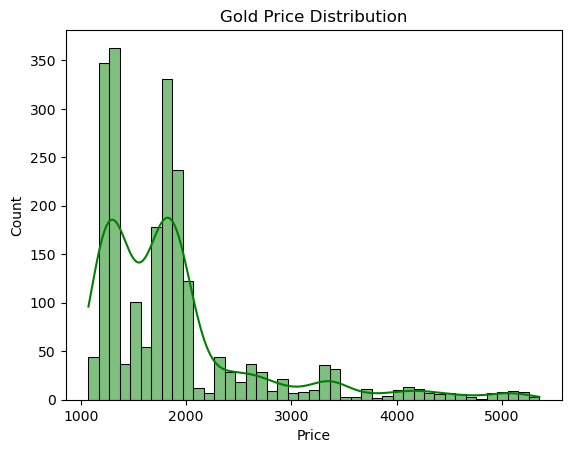

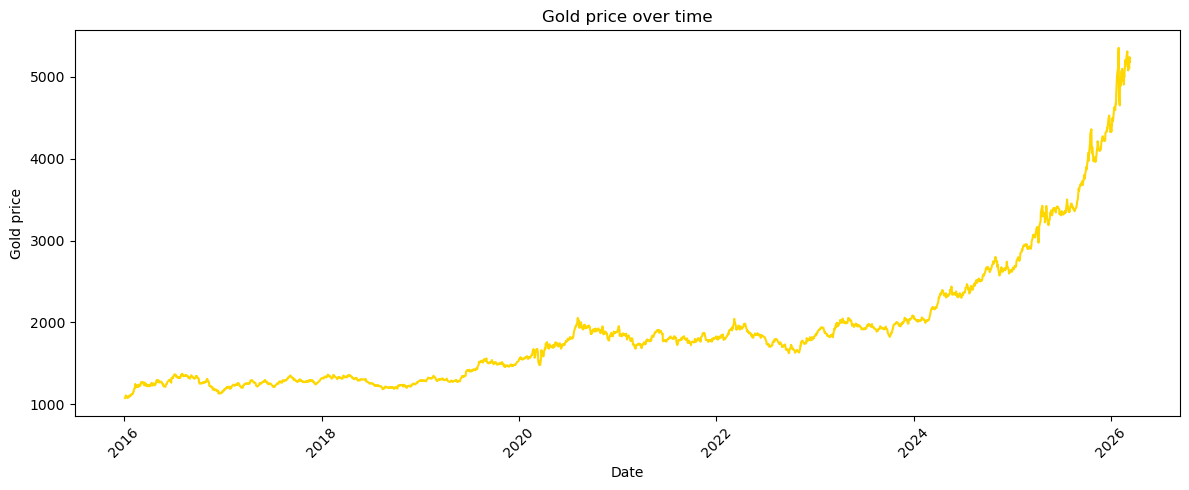

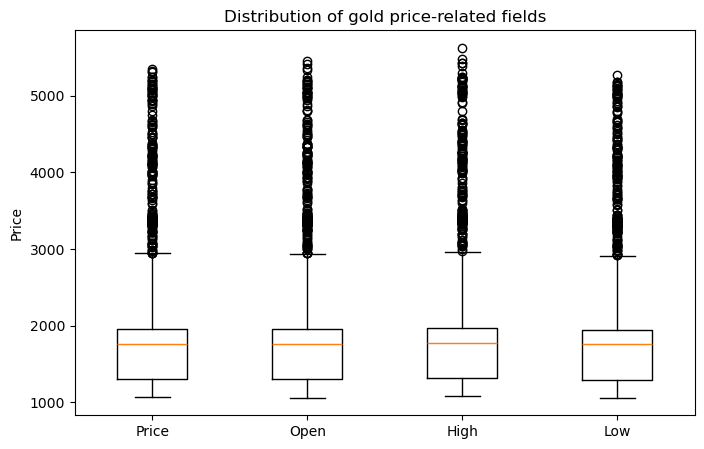

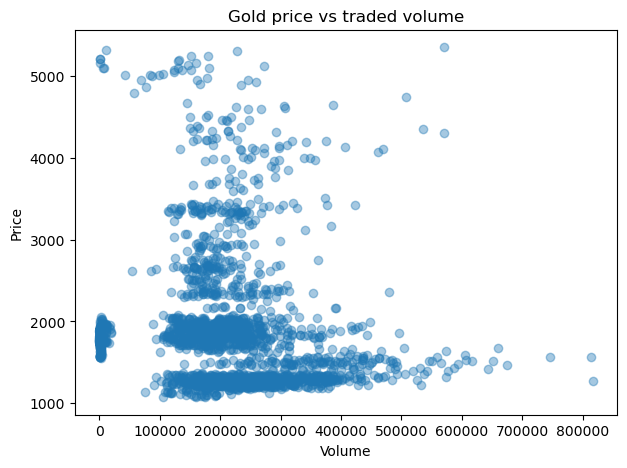

In [16]:
# ------------------------------------------------------------
# 3. Exploratory data analysis (EDA)
# ------------------------------------------------------------
# Correlation matrix (numeric columns only)
correlation = gold_data.drop(columns=['Date']).corr()

# Heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',
            annot=True, annot_kws={'size':8}, cmap='BuPu')
plt.title('Feature Correlations')
plt.show()

print("\nCorrelation with Price:")
print(correlation['Price'])

# Distribution of gold price
sns.histplot(gold_data['Price'], color='green', kde=True)
plt.title('Gold Price Distribution')
plt.show()

# Time series of gold price
plt.figure(figsize=(12, 5))
plt.plot(gold_data['Date'], gold_data['Price'], color='gold')
plt.xlabel('Date')
plt.ylabel('Gold price')
plt.title('Gold price over time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplots of price fields
plt.figure(figsize=(8, 5))
price_cols = ['Price', 'Open', 'High', 'Low']
plt.boxplot([gold_data[c] for c in price_cols], labels=price_cols)
plt.ylabel('Price')
plt.title('Distribution of gold price-related fields')
plt.show()

# Scatter: Volume vs Price
plt.figure(figsize=(7, 5))
plt.scatter(gold_data['Vol.'], gold_data['Price'], alpha=0.4)
plt.xlabel('Volume')
plt.ylabel('Price')
plt.title('Gold price vs traded volume')
plt.show()

In [17]:
# ------------------------------------------------------------
# 4. Prepare data for modelling
# ------------------------------------------------------------
X = gold_data.drop(['Date', 'Price'], axis=1)
Y = gold_data['Price']

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", Y.shape)

# Train / test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


Feature matrix shape: (2235, 5)
Target vector shape: (2235,)


In [18]:
# ------------------------------------------------------------
# 5. Train Random Forest Regressor
# ------------------------------------------------------------
regressor = RandomForestRegressor(n_estimators=100, random_state=2)
regressor.fit(X_train, Y_train)

# Predictions
test_predictions = regressor.predict(X_test)
print("\nSample predictions:", test_predictions[:5])

# Evaluation: R² score
error_score = r2_score(Y_test, test_predictions)  # corrected import usage
print('R squared error is:', error_score)


Sample predictions: [4346.4435 1660.626  1773.803  1311.438  1967.384 ]
R squared error is: 0.9997696054279388


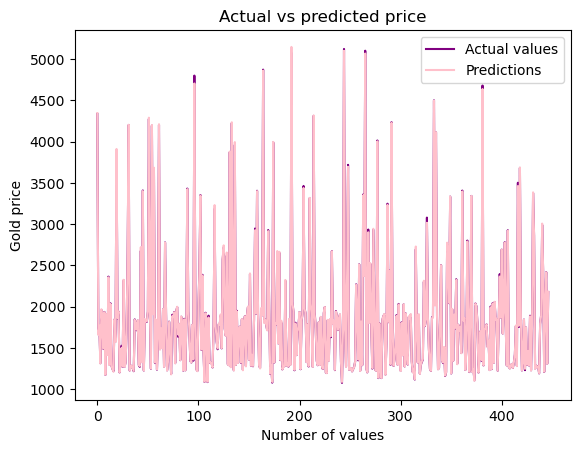

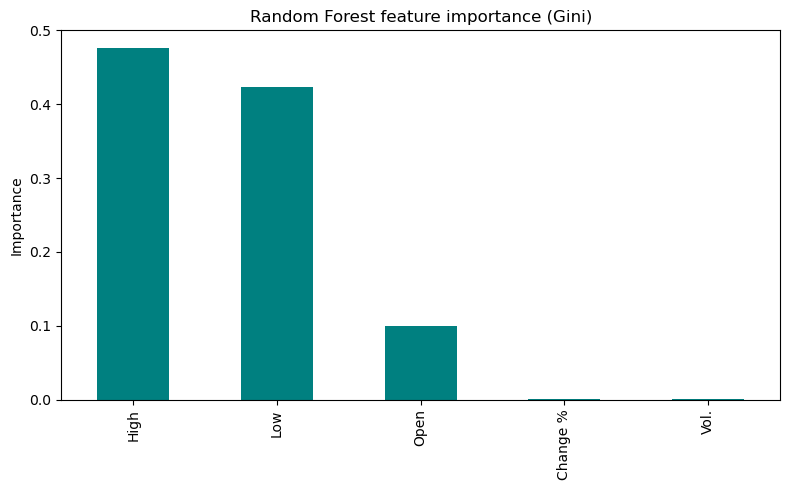

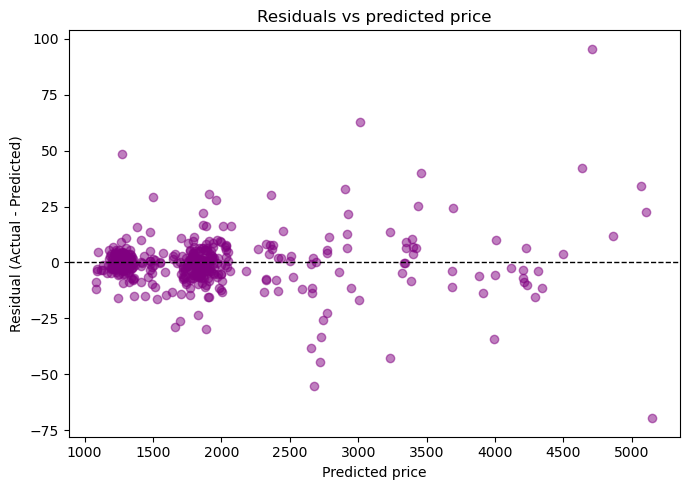

In [19]:
# ------------------------------------------------------------
# 6. Visualise model performance
# ------------------------------------------------------------
# Actual vs predicted plot
Y_test_list = list(Y_test)
plt.plot(Y_test_list, color='purple', label='Actual values')
plt.plot(test_predictions, color='pink', label='Predictions')
plt.xlabel('Number of values')
plt.ylabel('Gold price')
plt.title('Actual vs predicted price')
plt.legend()
plt.show()

# Feature importance from Random Forest
feature_importances = pd.Series(regressor.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(8, 5))
feature_importances.plot(kind='bar', color='teal')
plt.ylabel('Importance')
plt.title('Random Forest feature importance (Gini)')
plt.tight_layout()
plt.show()

# Residuals plot
residuals = Y_test - test_predictions
plt.figure(figsize=(7, 5))
plt.scatter(test_predictions, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs predicted price')
plt.tight_layout()
plt.show()


--- SHAP Explanation ---


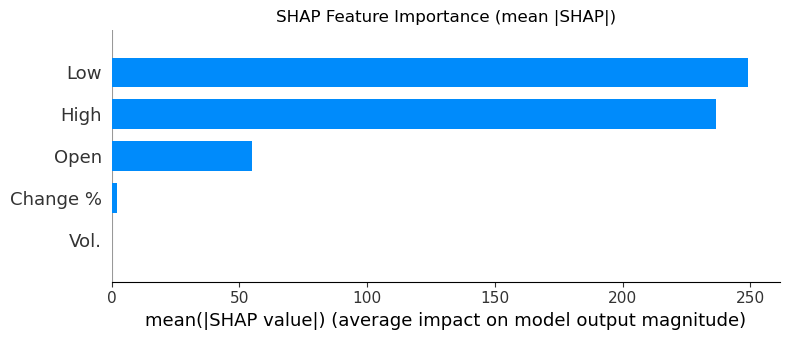

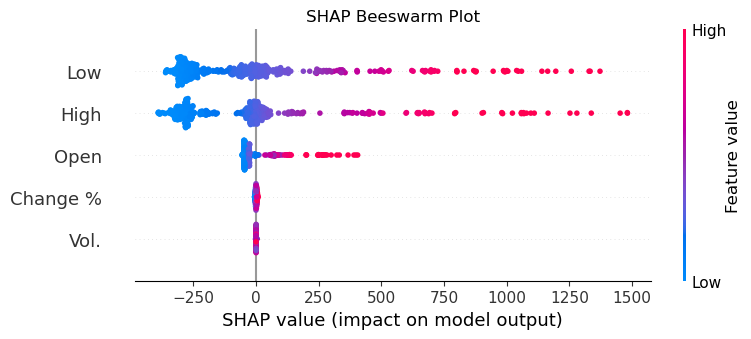

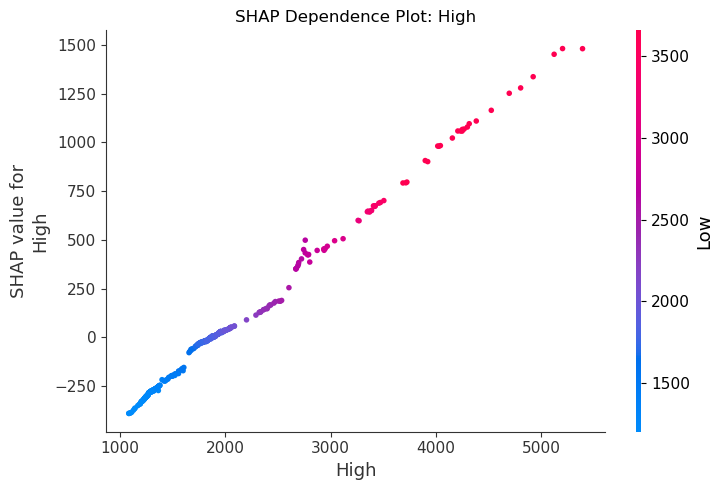

SHAP analysis completed.


In [20]:
# ------------------------------------------------------------
# 7. SHAP Model Explanation (added functionality)
# ------------------------------------------------------------
print("\n--- SHAP Explanation ---")

# Create a TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(regressor)

# Compute SHAP values for the test set (you can also use a subset for speed)
shap_values = explainer.shap_values(X_test)

# 7.1 SHAP summary bar plot (mean absolute SHAP values) – global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

# 7.2 SHAP beeswarm plot – shows distribution of SHAP values per feature
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

# 7.3 (Optional) SHAP dependence plot for the most important feature
# Identify top feature from SHAP bar plot
top_feature = feature_importances.index[0]  # e.g., 'Open'
shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f"SHAP Dependence Plot: {top_feature}")
plt.tight_layout()
plt.show()

print("SHAP analysis completed.")